In [1]:
from ocpa.objects.log.importer.ocel import factory as ocel_import_factory

import Super_Variant_Hierarchy as SVH
import Super_Variant_Visualization as SVV
import Intra_Variant_Generation as IAVG
import Summarization_Selection as IASS
import Inter_Variant_Generation as IEVG
import Inter_Lane_Alignment as ILA

from Evaluation import utility as utils
from config import P2P_LOG, TEST_LOG_2, TEST_LOG_1

VISUALIZE_INTERMEDIATE_RESULTS = False

## Evaluation Settings

In [2]:
# EVALUATION Settings
ILA.ALIGN = False
filename = P2P_LOG

# Import Log
ocel = ocel_import_factory.apply(file_path=filename)

if VISUALIZE_INTERMEDIATE_RESULTS:
    utils.visualize_variant_summarization_step(ocel)

## Intra-Variant Summarization

In [3]:
# Generate and select intra-variant summarizations
all_summarizations, per_variant_dict, per_encoding_dict = IAVG.complete_intra_variant_summarization_from_process(ocel)
intra_variant_summarizations = IASS.intra_variant_summarization_selection(all_summarizations, per_variant_dict, per_encoding_dict)

# print("All summ", all_summarizations, "\n\n\n")
# print("Intra var summ", intra_variant_summarizations)

if VISUALIZE_INTERMEDIATE_RESULTS:
    utils.visualize_intra_summarizations(intra_variant_summarizations, all_summarizations)

  0%|          | 0/315 [00:00<?, ?it/s]

 
Summarizing variant 0 of the process...
 
Summarizing variant 1 of the process...
 
Summarizing variant 2 of the process...
 
Summarizing variant 3 of the process...
 
Summarizing variant 4 of the process...
 
Summarizing variant 5 of the process...
Could not summarize variant 5.
 
Summarizing variant 6 of the process...
Could not summarize variant 6.
 
Summarizing variant 7 of the process...
 
Summarizing variant 8 of the process...
Could not summarize variant 8.
 
Summarizing variant 9 of the process...
 
Summarizing variant 10 of the process...
Could not summarize variant 10.
 
Summarizing variant 11 of the process...
 
Summarizing variant 12 of the process...
Could not summarize variant 12.
 
Summarizing variant 13 of the process...
Could not summarize variant 13.
 
Summarizing variant 14 of the process...
Could not summarize variant 14.
 
Summarizing variant 15 of the process...
Could not summarize variant 15.
 
Summarizing variant 16 of the process...
Could not summarize varian

INFO:gurobipy:Restricted license - for non-production use only - expires 2026-11-23



 Objective value: 15


 Variable values: 

0: 1.0
1: 1.0
2: 1.0
3: 1.0
4: 1.0
5: 1.0
6: 1.0
7: 1.0
8: 1.0
9: 1.0
10: 1.0
11: 1.0
12: 1.0
13: 1.0
14: 1.0
-----------------------------
15/15unique summarizations have been selected for the Between-Lane Summarization.


## Inter-Variant Summarization

Initial super variants [<Super_Variant_Definition.SuperVariant object at 0x12d15bcd0>, <Super_Variant_Definition.SuperVariant object at 0x12d15ae90>, <Super_Variant_Definition.SuperVariant object at 0x12d15a590>, <Super_Variant_Definition.SuperVariant object at 0x12d158c10>, <Super_Variant_Definition.SuperVariant object at 0x12d159c10>, <Super_Variant_Definition.SuperVariant object at 0x12d15bd50>, <Super_Variant_Definition.SuperVariant object at 0x12d2b8790>, <Super_Variant_Definition.SuperVariant object at 0x12d153ad0>, <Super_Variant_Definition.SuperVariant object at 0x12d15b3d0>, <Super_Variant_Definition.SuperVariant object at 0x12d1585d0>, <Super_Variant_Definition.SuperVariant object at 0x12ca89990>, <Super_Variant_Definition.SuperVariant object at 0x12ca88b10>, <Super_Variant_Definition.SuperVariant object at 0x12d188fd0>, <Super_Variant_Definition.SuperVariant object at 0x12d16ad90>, <Super_Variant_Definition.SuperVariant object at 0x12d188190>] 



Evaluating the decision of 

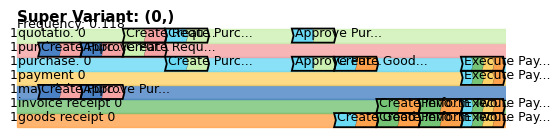

Interaction not found.


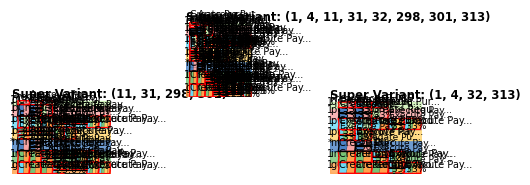

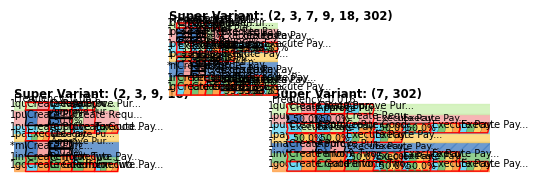

In [4]:
# MODE 1 - Frequency Distribution and No Nested Structures
IEVG.NESTED_STRUCTURES = False
initial_super_variants = intra_variant_summarizations

print("Initial super variants", initial_super_variants, "\n\n\n")

# Generating 3 hierarchies from the initial super variants with uniform frequency distribution
hierarchies, final_super_variants = IEVG.generate_super_variant_hierarchy(
    initial_super_variants, 3, frequency_distribution_type=IEVG.Distribution.UNIFORM)

# print("Hierarchies", hierarchies, "\n\n\n")
# print("Final super variants", final_super_variants, "\n\n\n")

# Visualizing each hierarchy top-down
for final_super_variant in final_super_variants[0]:
    # SVH.explore_hierarchy_bottom_up(final_super_variant)
    SVH.explore_hierarchy_top_down(final_super_variant)

# utils.print_hierarchy_costs(hierarchies)

Evaluating the decision of matching lane (4,) of Super Variant 1 with the lane (3,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (1,) of Super Variant 1 with the lane (1,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (0,) of Super Variant 1 with the lane (0,) of Super Variant 2.
Propagating.
Propagating the last decision among [] and [].
Empty. The rest is optional.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (4,) of Super Variant 1 with the lane (5,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (1,) of Super Variant 1 with the lane (1,) of Super Variant 2.
Not propagating.
This is

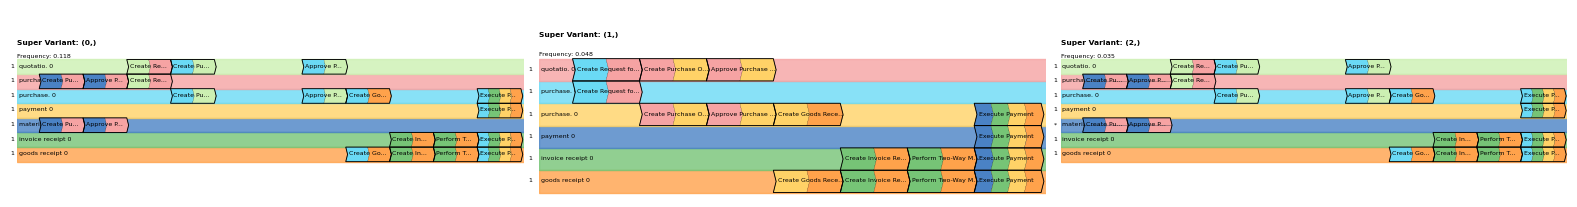

In [21]:
# MODE4/PerfEval - Ultimate Super Variant and No Nested Structures

IEVG.NESTED_STRUCTURES = False
SVH.MODE = SVH.MODE.NO_FREQUENCY
initial_super_variants = intra_variant_summarizations

hierarchies, final_super_variants = IEVG.generate_super_variant_hierarchy(intra_variant_summarizations, base=4)

for hierarchy in hierarchies:
    SVH.explore_hierarchy_bottom_up(hierarchy)

# [SVH.explore_hierarchy_bottom_up(hierarchy) for hierarchy in hierarchies]
# utils.build_triad_hierarchy(initial_super_variants)

In [15]:
# MODE2 - Pre-Classification and Nested Structures
# CAREFUL, TAKES FOREVER
IEVG.NESTED_STRUCTURES = False
VISUALIZE_INTERMEDIATE_RESULTS = False

initial_super_variants = IEVG.classify_initial_super_variants_by_activity(intra_variant_summarizations, "Cancel application")

if VISUALIZE_INTERMEDIATE_RESULTS:
    # All initial super variants that contain a "Cancel application" activity
    for summarization in initial_super_variants[0]:
        SVV.visualize_super_variant(summarization)

    # All initial super variants that do not contain a "Cancel application" activity
    for summarization in initial_super_variants[1]:
        SVV.visualize_super_variant(summarization)

# Generating a hierarchy for both classes of initial super variants
hierarchies, final_super_variants = IEVG.generate_super_variant_hierarchy(initial_super_variants[1], frequency_distribution_type=IEVG.Distribution.UNIFORM)

# Visualizing each hierarchy top-down
for final_super_variant in final_super_variants:
    SVH.explore_hierarchy_top_down(final_super_variant[0])

# utils.print_hierarchy_costs(hierarchies)

Evaluating the decision of matching lane (4,) of Super Variant 1 with the lane (3,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (1,) of Super Variant 1 with the lane (1,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (0,) of Super Variant 1 with the lane (0,) of Super Variant 2.
Propagating.
Propagating the last decision among [] and [].
Empty. The rest is optional.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (4,) of Super Variant 1 with the lane (5,) of Super Variant 2.
Not propagating.
This is so far the most optimal decision.
------------------------------------
Evaluating the decision of matching lane (1,) of Super Variant 1 with the lane (1,) of Super Variant 2.
Not propagating.
This is

KeyboardInterrupt: 

In [ ]:
# MODE3 - Ultimate Super Variant and Nested Structures
IEVG.NESTED_STRUCTURES = True
SVH.MODE = SVH.MODE.NO_FREQUENCY
initial_super_variants = intra_variant_summarizations

utils.build_triad_hierarchy(initial_super_variants)

## Alignment Settings

In [ ]:
from Evaluation.utility import manual_alignment

# MODE4/Publication - Ultimate Super Variant and No Nested Structures

IEVG.NESTED_STRUCTURES = False
SVH.MODE = SVH.MODE.NO_FREQUENCY
initial_super_variants = intra_variant_summarizations

# Generating 3 hierarchies from the initial super variants with uniform frequency distribution
hierarchies, final_super_variants = IEVG.generate_super_variant_hierarchy(initial_super_variants, base=2)


#positions = [[3,4,5,[6,6,[[6]]],7],[4,5,[6,6,[[6]]],7],[[6,6,[[6]]],7],[1,2,3,[6,6,[[6]]],7],[0],[0,1,2]]
#interactions = [[0,0],[4,4],[1,1],[5,5],[3,3],[2,2],[6,6,6,6],[7,7,7,7]]
#SVV.visualize_super_variant(manual_alignment(hierarchies[0][2][0][0][0],positions,interactions))

#positions = [[5,6,7,8],[6,7,8],[0,[1,1,[[1],[1]]]],[8],[3,4,5,8],[0,[1,1,[[1],[1]]],2],[2,3,4]]
#interactions = [[0,0],[6,6],[2,2],[3,3],[1,1],[1,1],[7,7],[5,5],[4,4],[8,8,8,8]]
#SVV.visualize_super_variant(manual_alignment(hierarchies[0][2][0][2][0],positions,interactions))

#positions = [[5,6,7,8],[6,7,8],[0,1],[8],[3,4,5,8],[0,1,2],[2,3,4]]
#interactions = [[0,0],[6,6],[2,2],[3,3],[1,1],[7,7],[5,5],[4,4],[8,8,8,8]]
#SVV.visualize_super_variant(manual_alignment(hierarchies[0][1][0][0][0],positions,interactions))

#positions = [[[5,9,[[5,6,7,8],[7,8,9]]],10],[6,7,[8,9,[[8],[8,9]]],10],[0,1],[[8,8,[[8]]],10],[3,4,5,[7,8,[[8],[7]]],10],[0,1,2],[2,3,4]]
#interactions = [[0,0],[6,6],[8,8],[2,2],[3,3],[1,1],[7,7],[9,9],[5,5],[4,4],[7,7],[8,8,8,8],[10,10,10,10]]
#super_variant = manual_alignment(hierarchies[0][1][0][2][0],positions,interactions)
#for i in range(len(super_variant.interaction_points)):
    #if(i ==2):
        #(super_variant.interaction_points)[i].exact_positions = [IED.RecursiveLanePosition(0,IED.BasePosition(1,8)),(hierarchies[0][1][0][2][0].interaction_points)[i].exact_positions[1]]
    #elif(i==7):
        #(super_variant.interaction_points)[i].exact_positions = [IED.RecursiveLanePosition(0,IED.BasePosition(1,9)),(hierarchies[0][1][0][2][0].interaction_points)[i].exact_positions[1]]
#SVV.visualize_super_variant(super_variant)

#positions = [[[5,9,[[5,6,7],[7,8,9]]],10],[6,7,8,9,10],[0,1],[10],[3,4,5,7,10],[0,1,2],[2,3,4]]
#interactions = [[0,0],[6,6],[2,2],[3,3],[1,1],[7,7],[5,5],[7,7],[4,4],[8,8],[9,9],[10,10,10,10]]
#SVV.visualize_super_variant(manual_alignment(hierarchies[0][1][0][3][0],positions,interactions))

#positions = [[5,6,7,8],[6,7,8],[0,1],[8],[3,4,5,8],[0,1,2],[2,3,4]]
#interactions = [[0,0],[6,6],[2,2],[3,3],[1,1],[7,7],[5,5],[4,4],[8,8,8,8]]
#SVV.visualize_super_variant(manual_alignment(hierarchies[0][1][0][4][0],positions,interactions))

#positions = [[[5,9,[[7,8,9],[5,6,7]]],10],[6,7,8,9,10],[0,1],[10],[3,4,5,7,10],[0,1,2],[2,3,4]]
#interactions = [[0,0],[0,0],[3,3],[5,5],[7,7],[1,1],[1,1],[2,2],[4,4],[6,6],[8,8],[7,7],[9,9],[10,10,10,10],[10,10,10,10]]
#SVV.visualize_super_variant(manual_alignment(hierarchies[0][0][0][5][0],positions,interactions))

#positions = [[[5,9,[[7,8,9],[5,6,7]]],10],[6,7,8,9,10],[0,1],[10],[3,4,5,7,10],[0,1,2],[2,3,4]]
#interactions = [[0,0],[0,0],[0,0],[3,3],[5,5],[7,7],[1,1],[1,1],[1,1],[2,2],[4,4],[6,6],[8,8],[7,7],[9,9],[10,10,10,10],[10,10,10,10]]
#SVV.visualize_super_variant(manual_alignment(hierarchies[0][0][0][8][0],positions,interactions))

#positions = [[[5,9,[[7,8,9],[5,6,7]]],10],[6,7,8,9,10],[0,1],[10],[3,4,5,7,10],[0,1,2],[2,3,4]]
#interactions = [[0,0],[0,0],[3,3],[7,7],[5,5],[1,1],[1,1],[2,2],[4,4],[8,8],[9,9],[6,6],[7,7],[10,10,10,10],[10,10,10,10]]
#SVV.visualize_super_variant(manual_alignment(hierarchies[0][0][0][6][0],positions,interactions))

#positions = [[5,6,7,8],[6,7,8],[0,1],[8],[3,4,5,8],[0,1,2],[2,3,4]]
#interactions = [[0,0],[0,0],[3,3],[5,5],[1,1],[1,1],[2,2],[4,4],[6,6],[7,7],[8,8,8,8]]
#SVV.visualize_super_variant(manual_alignment(hierarchies[0][0][0][9][0],positions,interactions))

#positions = [[5,6,7,8],[6,7,8],[0,1],[8],[3,4,5,8],[0,1,2],[2,3,4]]
#interactions = [[0,0],[0,0],[3,3],[5,5],[1,1],[1,1],[2,2],[4,4],[6,6],[7,7],[8,8,8,8]]
#VV.visualize_super_variant(manual_alignment(hierarchies[0][0][0][2][0],positions,interactions))


for i in range(len(hierarchies[0][2][0][1][0].interaction_points)):
    print((hierarchies[0][2][0][1][0].interaction_points)[i])
#for i in range(10):
SVV.visualize_super_variant(hierarchies[0][2][0][1][0])

positions = [
[[5,11,[[7,8,9,11],[9,10,11],[5,6,7]]],12]
,[[6,7,[[6,7]]],8,9,[10,11,[[11],[10,11]]],12]
,[0,1]
,[[11,11,[[11]]],12]
,[3,4,[5,5,[[5]]],7,[9,11,[[11],[9]]],12]
,[0,1,2]
,[2,3,4]]
interactions = [[0,0],[6,6],[2,2],[3,3],[1,1],[7,7],[5,5],[4,4],[8,8],[7,7],[9,9],[9,9],[11,11,11,11],[12,12,12,12]]
super_variant = manual_alignment(hierarchies[0][2][0][1][0],positions,interactions)
#super_variant.interaction_points.append(IED.InteractionPoint('Create Invoice Receipt',lanes,('invoice receipt','goods receipt'),10,[IED.]))
SVV.visualize_super_variant(super_variant)